# Chapter C. Multiple Hypothesis Testing

## Learning Objectives

After completing this chapter, you should be able to:
1. Distinguish per-test Type I error, FWER（家族错误率）, FDR（错误发现率）, and FDP.
2. Compute BH-adjusted q-values across the whole candidate-by-lag family.
3. Explain why correlated or invalid p-values can compromise FDR control.
4. Compare Bonferroni, BH, and BY adjustments on reproducible data.
5. Distinguish complete-null FDR from mixed-null mean FDP.

**Connection to STARM:** The examples mirror the binary outcome, fixed antecedent indicators, lagged transactions, and overlapping spatial supports in the STARM manuscript. They are teaching examples, not reproductions of manuscript results.

> **Teaching philosophy:** start with the general statistical problem, build mathematical intuition, and use STARM as one illustrative case study. The new sections precede the original computational labs.

## Why Study This? — Motivation, Scope, and Real-World Problems

When we test many hypotheses, individual error rates accumulate: this is the **multiple comparisons problem (多重比较问题)**. This appears in genomics, neuroimaging, high-throughput screening, sensor networks, and algorithmic pattern mining. If 1,000 independent true nulls are tested at 0.05, the expected number of false rejections is 50.

**Questions it answers:** What does “5% error” mean across a large research search? How many false findings can we tolerate? When do dependence and data-driven selection invalidate a correction?

---

## Conceptual Roadmap

**Scientific problem → statistical representation → assumptions → mathematics → computational experiment → diagnostics → interpretation.**

The chapters are standalone: STARM is a later application, not the reason these mathematical ideas exist.

## Foundations and Mathematical Derivations

### Error quantities and why they differ
Let $V$ denote false discoveries, $S$ true discoveries, $R=V+S$, and $M$ the number of tests. Define

$$\mathrm{FWER}=P(V\ge1),\qquad\mathrm{FDP}=\frac{V}{\max(R,1)},\qquad\mathrm{FDR}=E[\mathrm{FDP}].$$

**FWER** (族错误率) protects against *any* false rejection; **FDR** (错误发现率) controls the *expected proportion* of false rejections. Under the complete null, $R=V$, so $\mathrm{FDR}=P(V>0)=\mathrm{FWER}$. With true signals present, they differ.

### Bonferroni, BH, and BY from first principles
Bonferroni rejects test $i$ if $p_i\le\alpha/M$: by the union bound $P(V>0)\le\sum_{i\in H_0}P(p_i\le\alpha/M)\le\alpha$, provided true-null p-values are valid. No independence is required.

**Benjamini–Hochberg (BH):** order $p_{(1)}\le\cdots\le p_{(M)}$; let $k^*=\max\{k:p_{(k)}\le k\alpha/M\}$. Reject $p_i\le p_{(k^*)}$; no rejections if no qualifying $k$. Standard BH control holds under independence or certain positive dependence (PRDS), assuming valid true-null p-values.

**Benjamini–Yekutieli (BY):** replace $\alpha$ with $\alpha/H_M$, $H_M=\sum_{j=1}^{M}1/j$. It controls FDR under arbitrary dependence *of valid p-values*, at an often substantial power cost. Neither BH nor BY fixes invalid marginal p-values.

### Correlation, selection, and hypothesis families
Nested tests (e.g. $A$ and $A\cap B$), repeated lags, shared data, and threshold scans create correlated p-values. Positive correlation by itself does not establish PRDS. If a rule is selected *using the outcomes* and then tested as if it were prespecified, selection bias may invalidate inference. A valid design may use outcome-independent filters, sample splitting, or explicit selective-inference methods.

### Critical thinking checkpoint
Before running code, write down which observations are assumed independent or exchangeable and explain why. Revisit this statement after inspecting the visualizations.

## Additional Derivation Visualization — General-Purpose Example

The following self-contained experiment illustrates a general statistical principle, not STARM-specific results. Check how the plot corresponds to the formulas above.

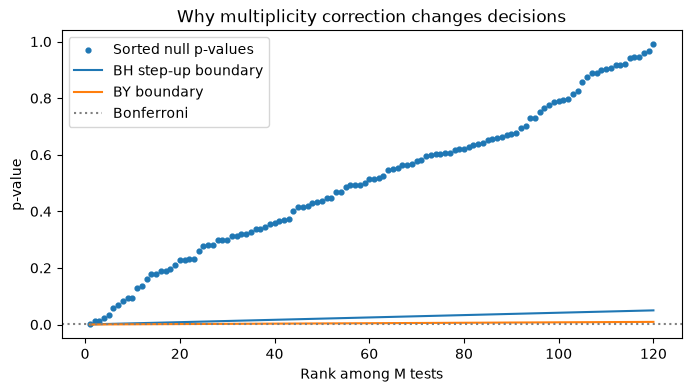

Expected false rejections under uncorrected alpha: 6.0


In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng=np.random.default_rng(2026)
M=120; alpha=.05
p=np.sort(rng.uniform(size=M)); idx=np.arange(1,M+1)
H=np.sum(1/idx)
fig,ax=plt.subplots(figsize=(8,4))
ax.scatter(idx,p,s=12,label='Sorted null p-values')
ax.plot(idx,alpha*idx/M,label='BH step-up boundary')
ax.plot(idx,alpha*idx/(M*H),label='BY boundary')
ax.axhline(alpha/M,color='gray',ls=':',label='Bonferroni')
ax.set(xlabel='Rank among M tests',ylabel='p-value',title='Why multiplicity correction changes decisions')
ax.legend();plt.show()
print('Expected false rejections under uncorrected alpha:',M*alpha)

```mermaid
flowchart LR
    A[Enumerate candidates × lags] --> B[Compute valid p-values]
    B --> C[Sort all p-values]
    C --> D[BH step-up threshold]
    D --> E[Identify R and V]
    E --> F[Estimate mean FDP over replicates]
```

This chapter follows the same structure as the supplied MCLP tutorial: conceptual workflow, formal definition, assumptions, a hand-worked example, executable Python experiments, sensitivity checks, common pitfalls, and a quiz.

---

## Formal Definition and Core Equations

### Notation

| Symbol | Meaning |
|---|---|
| $M$ | total number of tested candidate-by-lag hypotheses |
| $R$ | number of rejected hypotheses |
| $V$ | number of false rejections（错误发现数量） |
| $\mathrm{FDP}$ | realized false discovery proportion |
| $\mathrm{FDR}$ | expectation of FDP |
| $\alpha$ | nominal target error level |

$$\mathrm{FDP}=\frac{V}{\max(R,1)},\qquad\mathrm{FDR}=E[\mathrm{FDP}].$$

$$p_{(k)}\le\frac{k\alpha}{M}\quad\text{(BH step-up criterion)},\qquad q_{(i)}=\min_{j\ge i}\frac{M p_{(j)}}j\wedge1.$$

Under the **complete null**, $V=R$, so $\mathrm{FDR}=P(R>0)$; this equality generally fails under a mixed null.

---

## Core Mechanisms and Concepts

### Families matter

STARM tests candidate × lag combinations, not just each antecedent separately. Fix the allowed antecedents and lag range in advance, and adjust across the complete tested family.

### FWER versus FDR

FWER controls the probability of any false rejection; FDR controls the expected fraction of rejected rules that are false, including repetitions with no rejections.

### Dependence caveat

BH provides guarantees for valid null p-values under specified dependence assumptions (such as independence and PRDS). Shared environmental conditions and nested rules do **not** automatically establish PRDS. BY is conservative under arbitrary dependence **if the input null p-values are valid**. Neither adjustment rescues invalid spatial permutations.

## Assumptions, Strengths, Limitations, and Trade-offs

Assume known hypothesis family, proper null p-values, and interpret the chosen correction under its theoretical dependence assumptions. Strength: explicit adjustment for extensive search. Limitation: a small empirical mixed-null mean FDP does not establish general FDR control.

**Trade-off:** aggressive screening and stronger correction can reduce false detections but may lower power for rare compound rules.

## Worked Toy Example

Five candidate-by-lag tests produce p-values $(0.001,0.012,0.020,0.070,0.40)$. At $\alpha=0.05$, compare each ordered p-value with $(1,2,3,4,5)\times0.05/5$. The largest passing rank determines all BH rejections up to that rank. Do **not** test each lag in its own family unless that is the prespecified scientific family.

## Python Lab: Set Up the Dataset

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import hypergeom, binom

SEED = 41020001
rng = np.random.default_rng(SEED)
print("Reproducible random seed:", SEED)

Reproducible random seed: 41020001


## Manually compute BH decisions

Implement BH and BY without an additional statistics package.

In [3]:
def bh_qvals(p):
 p=np.asarray(p,float);m=len(p);order=np.argsort(p);ranks=np.arange(1,m+1)
 q_sorted=np.minimum.accumulate((m*p[order]/ranks)[::-1])[::-1]
 q=np.empty(m);q[order]=np.minimum(q_sorted,1);return q
p=np.array([.001,.012,.020,.070,.40]);q=bh_qvals(p)
print(pd.DataFrame({'p':p,'BH q':q,'BH reject':q<=.05,'Bonferroni reject':p<=.05/len(p)}))

       p      BH q  BH reject  Bonferroni reject
0  0.001  0.005000       True               True
1  0.012  0.030000       True              False
2  0.020  0.033333       True              False
3  0.070  0.087500      False              False
4  0.400  0.400000      False              False


**Interpretation.** Sort over the complete family. BH thresholding is not the same as testing each raw p-value at 0.05.

## Compare BH and BY

BY adds the harmonic factor H_M and is more conservative.

In [4]:
H=sum(1/j for j in range(1,len(p)+1))
q_by=np.minimum(1,q*H)
print(pd.DataFrame({'p':p,'BH_q':q,'BY_q':q_by}).round(4))

       p    BH_q    BY_q
0  0.001  0.0050  0.0114
1  0.012  0.0300  0.0685
2  0.020  0.0333  0.0761
3  0.070  0.0875  0.1998
4  0.400  0.4000  0.9133


**Interpretation.** The BY correction addresses arbitrary dependence of VALID p-values; it cannot fix the anti-conservatism of a misspecified spatial reference.

## Simulate complete-null family rejection

Independent uniform p-values let us see how the correction works when assumptions hold.

In [5]:
R=2500;M=45
ps=rng.uniform(size=(R,M))
any_bh=np.array([(bh_qvals(v)<=.05).any() for v in ps])
any_raw=np.array([(v<=.05).any() for v in ps])
print({'raw_any_rejection':any_raw.mean(),'BH_complete_null_FDR':any_bh.mean()})

{'raw_any_rejection': np.float64(0.9004), 'BH_complete_null_FDR': np.float64(0.0456)}


**Interpretation.** Under complete null, FDR is the probability of at least one rejection. This simple experiment has independent p-values, unlike spatial overlap.

## Simulate a mixed-null family

Calculate FDP on each replicate, including replicates with zero discoveries.

{'mean_FDP_FDR_estimate': np.float64(0.034792857142857146), 'true_positive_fraction': np.float64(0.17793333333333336)}


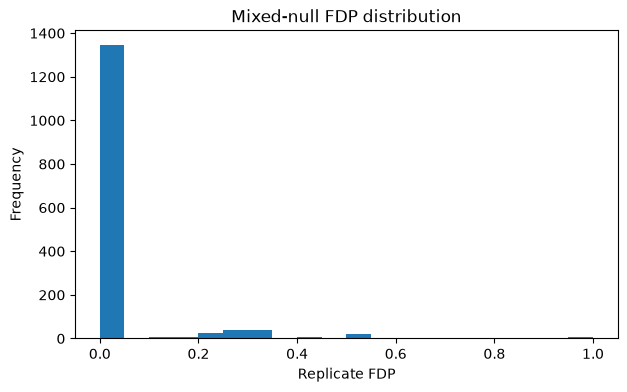

In [6]:
R=1500;M0=35;M1=10;fdps=[];powers=[]
for _ in range(R):
 p0=rng.uniform(size=M0);p1=rng.beta(.3,1,size=M1)
 rej=bh_qvals(np.r_[p0,p1])<=.05
 fdps.append(rej[:M0].sum()/max(1,rej.sum()))
 powers.append(rej[M0:].mean())
print({'mean_FDP_FDR_estimate':np.mean(fdps),'true_positive_fraction':np.mean(powers)})
fig,ax=plt.subplots(figsize=(7,4));ax.hist(fdps,bins=20);ax.set(xlabel='Replicate FDP',ylabel='Frequency',title='Mixed-null FDP distribution');plt.show()

**Interpretation.** A low mean FDP can coexist with poor power; the number of true rules and effect strength affect performance.

---

## Common Pitfalls and Misunderstandings

- Reporting $V/R$ after pooling all simulations is not the same as averaging replicate FDPs.
- A complete-null rejection rate and mixed-null FDR answer different questions.
- Nested rules and nearby lags can yield correlated p-values; correlation alone proves neither BH validity nor failure.
- BH uses one prespecified family; post-hoc family changes invalidate naive interpretation.
- BY does not correct an invalid randomization test.

---

## Quiz — Self-Assessment (Answers Hidden)

Try each question before expanding **Answer**. The folded format follows the supplied `mclp.ipynb` template.

### Q1: In a complete-null experiment, FDR equals what?

A. Mean number of discoveries  
B. Probability of any rejection  
C. Statistical power  
D. Sample size

<details>
<summary>Answer</summary>

**B. Every discovery is false; FDP is 1 if any rejection occurs and 0 otherwise.**

</details>

---

### Q2: Can BY rescue p-values from a misspecified permutation model?

A. Always  
B. Only for M>100  
C. No  
D. Only for positively correlated tests

<details>
<summary>Answer</summary>

**C. BY assumes individually valid true-null p-values.**

</details>

---

### Q3: What is the central difference between FWER and FDR?

A. FDR controls probability of any error  
B. FWER controls any false rejection; FDR controls expected false fraction  
C. Both are identical always  
D. FDR needs normality

<details>
<summary>Answer</summary>

**B. They correspond to different scientific error budgets.**

</details>

---

### Q4: Why must a study define its test family before adjusting?

A. To reduce plotting time  
B. To select only significant results  
C. The number and selection of tested claims influence multiplicity and validity  
D. To force independence

<details>
<summary>Answer</summary>

**C. Changing the family after seeing outcomes can induce selection bias.**

</details>

---

### Reflection Question (no prescribed solution)

Name one assumption violation in your own research area and propose a simulation to measure how much it matters.


---

## Suggested Reading and STARM Crosswalk

- Agrawal & Srikant (1994): frequent-itemset search (background).
- Hope (1968); Phipson & Smyth (2010): randomization/Monte Carlo p-values (Chapter B).
- Benjamini & Hochberg (1995); Benjamini & Yekutieli (2001): multiple testing and dependence (Chapter C).
- Baddeley, Rubak & Turner (2015): spatial point patterns (Chapter D).
- Winkler et al. (2014): exchangeability blocks and permutation designs (Chapters B, D, E).
- STARM manuscript: Sections 3.3–3.6 for reference assumptions; Section 4 for simulations; Sections 5–6 for empirical limitations.

**Practice task:** Write a short reviewer note distinguishing a descriptive association from an inferential discovery, explicitly naming the null model and its assumptions.